#Regular Expression#

2024/ PBA/ Irmasari Hafidz


Regex atau regular expressions, a.k.a. RE, re, regex, regexp, regex patterns.

Regex in Python docs dapat diakses di: https://docs.python.org/3/library/re.html

Pola dan strings yang bisa dicari:
*   Unicode strings (str)
*   8-bit strings (bytes)

Library yang dipakai adalah re

In [ ]:
import re

## Input dari .txt (towels.txt)  dari folder sample_data di akun Google Colab masing-masing.

In [ ]:
import pandas as pd
!cat 'sample_data/towels.txt'

The Hitch Hiker's Guide to the Galaxy has a few things to say on the subject of towels.
A towel, it says, is about the most massively useful thing an interstellar hitchhiker can have.  Partly it has great
practical value - you can wrap it around you for warmth as you bound across the cold moons of Jaglan Beta; you can lie
on it on the brilliant marble-sanded beaches of Santraginus V, inhaling the heady sea vapours; you can sleep under it
beneath the stars which shine so redly on the desert world of Kakrafoon; use it to sail a mini raft down the slow heavy
river Moth; wet it for use in hand-to- hand-combat; wrap it round your head to ward off noxious fumes or to avoid the
gaze of the Ravenous Bugblatter Beast of Traal (a  mindboggingly stupid animal, it assumes that if you can't
see it, it can't see you - daft as a bush, but very ravenous); you can wave your towel in emergencies as a
distress signal, and of course dry yourself off with it if it still seems to be clean enough.  More impo

Teks merupakan paragraf yang menceritakan tentang towels. Jika kita mencari term towel, maka akan muncul juga pencarian towels (plural dengan s).
![image-6.png](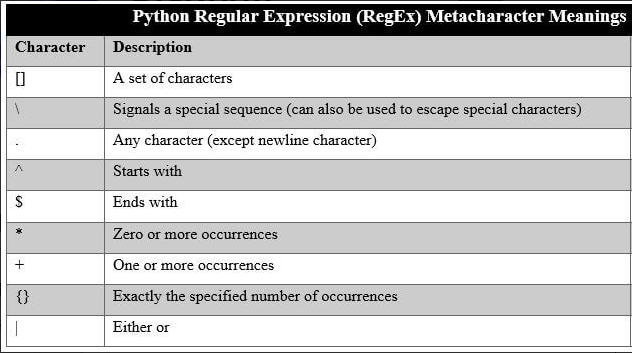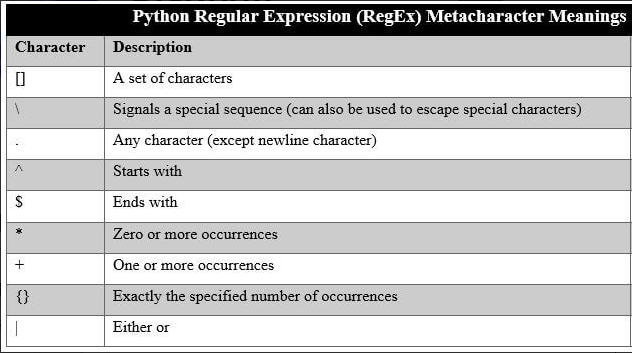)
 the string "towel" as well as as the string "towels".


In [ ]:
!grep "towel" sample_data/towels.txt

The Hitch Hiker's Guide to the Galaxy has a few things to say on the subject of towels.
A towel, it says, is about the most massively useful thing an interstellar hitchhiker can have.  Partly it has great
see it, it can't see you - daft as a bush, but very ravenous); you can wave your towel in emergencies as a
towel has immense psychological value.  For some reason, if a strag (strag: non-hitch hiker) discovers that a hitch
hiker has his towel with him, he will automatically assume that he is also in possession of a toothbrush, face flannel,
of the galaxy, rough it, slum it, struggle against terrible odds, win through, and still knows where his towel is is


In [ ]:
!grep "\(H\|h\)itch *\(H\|h\)iker" sample_data/towels.txt

The Hitch Hiker's Guide to the Galaxy has a few things to say on the subject of towels.
A towel, it says, is about the most massively useful thing an interstellar hitchhiker can have.  Partly it has great
towel has immense psychological value.  For some reason, if a strag (strag: non-hitch hiker) discovers that a hitch
Furthermore, the strag will then happily lend the hitch hiker any of these or a dozen other items that the hitch
Douglas Adams:  The Hitchhiker's Guide to the Galaxy


In [ ]:
# Read file contents as a single string
with open('sample_data/towels.txt') as f:
    hh_string = f.read()
b
# Define the regex pattern
pattern = '.*[H|h]itch *[H|h]iker.*'
regex = re.compile(pattern)

# Get list: each item is string with line that has variant of hitchhiker in it
regex.findall(hh_string)

["The Hitch Hiker's Guide to the Galaxy has a few things to say on the subject of towels.",
 'A towel, it says, is about the most massively useful thing an interstellar hitchhiker can have.  Partly it has great',
 'towel has immense psychological value.  For some reason, if a strag (strag: non-hitch hiker) discovers that a hitch',
 'Furthermore, the strag will then happily lend the hitch hiker any of these or a dozen other items that the hitch',
 "Douglas Adams:  The Hitchhiker's Guide to the Galaxy"]

In [ ]:
# Define the regex pattern
pattern = '(.*((H|h)itch *(H|h)iker).*)'
regex = re.compile(pattern)

# Get list: each item is string with line that has variant of hitchhiker in it
regex.findall(hh_string)

[("The Hitch Hiker's Guide to the Galaxy has a few things to say on the subject of towels.",
  'Hitch Hiker',
  'H',
  'H'),
 ('A towel, it says, is about the most massively useful thing an interstellar hitchhiker can have.  Partly it has great',
  'hitchhiker',
  'h',
  'h'),
 ('towel has immense psychological value.  For some reason, if a strag (strag: non-hitch hiker) discovers that a hitch',
  'hitch hiker',
  'h',
  'h'),
 ('Furthermore, the strag will then happily lend the hitch hiker any of these or a dozen other items that the hitch',
  'hitch hiker',
  'h',
  'h'),
 ("Douglas Adams:  The Hitchhiker's Guide to the Galaxy",
  'Hitchhiker',
  'H',
  'h')]

RE metacharacters that can be used in Python: (Ref: Justin Bois Regex's, lihat link Reference)

|     Metacharacter   |   Description   |
|:------------------:|-----------------|
| `.`                   | (dot) The ultimate wildcard. It matches any character other than the newline character (`\n`). If it is desireable to also match `\n` the alternative mode (`re.DOTALL`) can be invoked.
| `^`                   | (caret) Matches the start of a new string and the position immediately after a newline character.
| `$`                   | Similar to caret but goes for the end of the string and the character preceeding the newline character.
| `*`                   | The Kleene star  `*` following a RE allows 0 or multiple repitition of the this expression.  `ab*c` will match `ac`, `abc`, `abbc`, `abbbc`, ...
| `+`                   | Similar to the Kleene star, but it matches 1 or more occurences of the preceding RE, thus `ab+c` matches `abc`, `abbc`, `abbbc`, but not `ac`.
| `?`                   | Matches 0 or 1 repetition of the RE. `ab?` matches `a`, and `ab`.
| `{m}`                   | Matches exactly `m` repeats. `a{3}` equals `aaa`
| `{m,n}`                  | Matches m to n repeats, `a{2,4}` yields `aa`, `aaa`, and `aaaa`. The lower and upper bounds are optional `a{,4}` is the same as `a{0,4}`. Omiting the upper bound `a{4,}` yields anything with four or more repetitions of `a`.
| `[]`                   | Square brackets are used to describe a set of characters eg: `\[atcg\]` matches, `a`, `t`, `c`, or `g`, `\[a-z\]` matches any lowercase ASCII letter. `\[0-2\]\[0,9\]` matches all numbers from 00 to 29. It is important to note that metacharacters lose their special function within sets. Thus, `[(a\*b+)]` matches `(`, `a`, `\\`, `\*`, `b`, `+`, and `)`.
| `\\`                   | The escape character `\\` makes sure that the following character is interpreted literally. The Kleene star (`*`) for example will be interpreted as a simple asterisk if prefaced by the escape character (`\\\*`)
| &#124;                  | Logical or
| `(...)`                   | matches whatever regular expression is inside the parentheses.  As we discussed, these serve to describe groupings.

Reference


* Justin Bois i35 Regular Expression https://justinbois.github.io/bootcamp/2020/lessons/l35_regular_expressions.html
Colab pages at  https://colab.research.google.com/github/justinbois/bootcamp/blob/gh-pages/2021/lessons/l35_regular_expressions.ipynb#scrollTo=9ndPMg67CBES
*   https://web.mit.edu/hackl/www/lab/turkshop/slides/regex-cheatsheet.pdf

Menulis halaman ini (PBAWeek5_RegexPython.ipynb) dengan Markdown: https://colab.research.google.com/notebooks/markdown_guide.ipynb

